### Q2(a) — Apply gamma correction to the L plane in L*a*b* and state the gamma value

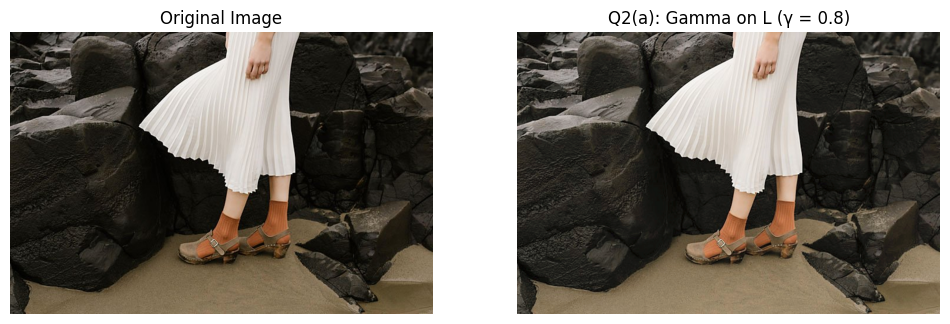

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_bgr = cv.imread('highlights_and_shadows.jpg')

# Convert BGR → RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert RGB → LAB
img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2LAB)

# Split channels
L, a, b = cv.split(img_lab)

# Normalize L channel
L_norm = L / 255.0

# Apply gamma correction (ONLY L channel)
gamma = 0.8
L_gamma = np.power(L_norm, gamma)

# Convert back
L_gamma_u8 = np.uint8(np.clip(L_gamma * 255, 0, 255))

# Merge channels
lab_corrected = cv.merge((L_gamma_u8, a, b))

# Convert back to RGB
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

# Display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_corrected)
plt.title('Q2(a): Gamma on L (γ = 0.8)')
plt.axis('off')

plt.show()

### Optional mapping curve

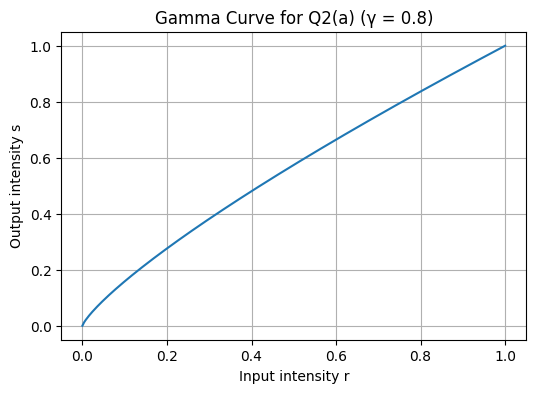

In [2]:
r = np.linspace(0, 1, 256)
s = r ** 0.8

plt.figure(figsize=(6,4))
plt.plot(r, s)
plt.title('Gamma Curve for Q2(a) (γ = 0.8)')
plt.xlabel('Input intensity r')
plt.ylabel('Output intensity s')
plt.grid(True)
plt.show()

### Python code for Q2(b) — L channel histograms

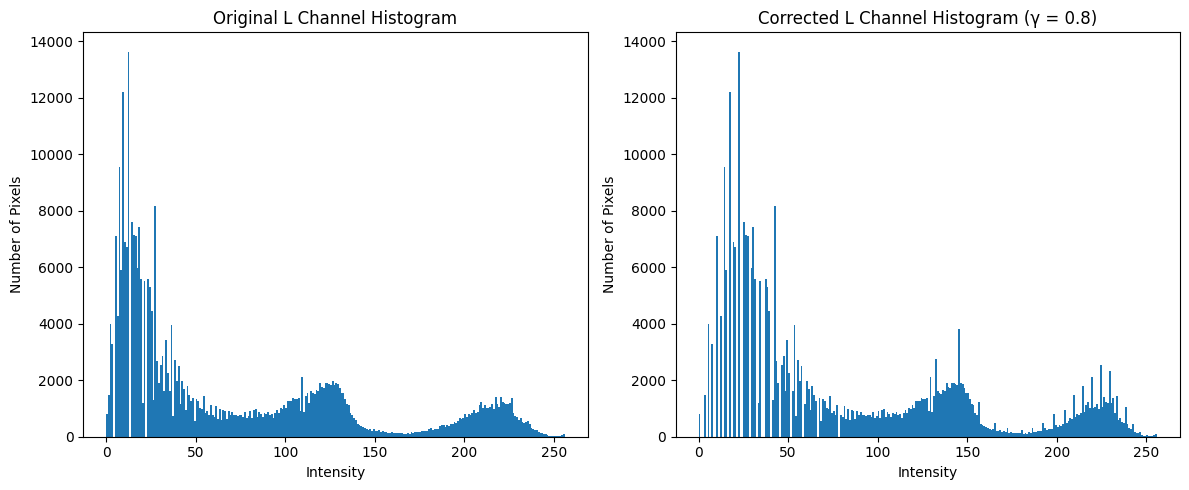

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(L.ravel(), bins=256, range=[0,256])
plt.title('Original L Channel Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')

plt.subplot(1,2,2)
plt.hist(L_gamma_u8.ravel(), bins=256, range=[0,256])
plt.title('Corrected L Channel Histogram (γ = 0.8)')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

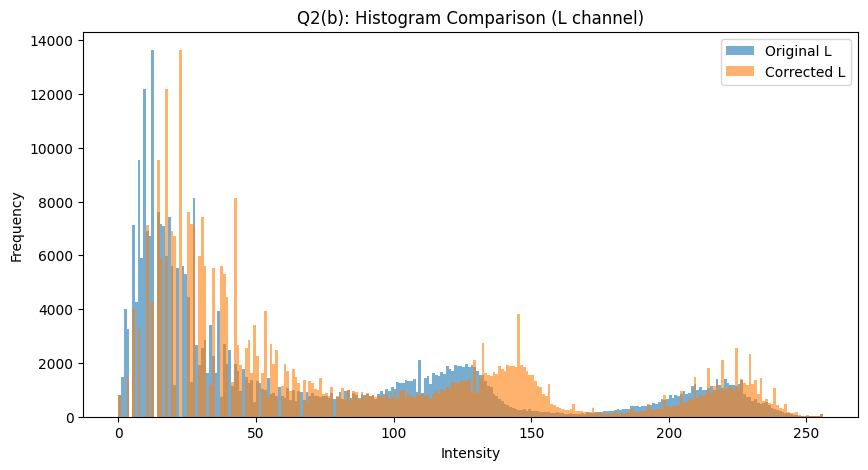

In [10]:
plt.figure(figsize=(10,5))

plt.hist(L.ravel(), bins=256, range=[0,256], alpha=0.6, label='Original L')
plt.hist(L_gamma_u8.ravel(), bins=256, range=[0,256], alpha=0.6, label='Corrected L')

plt.title('Q2(b): Histogram Comparison (L channel)')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.show()

## full visual summary for Q2

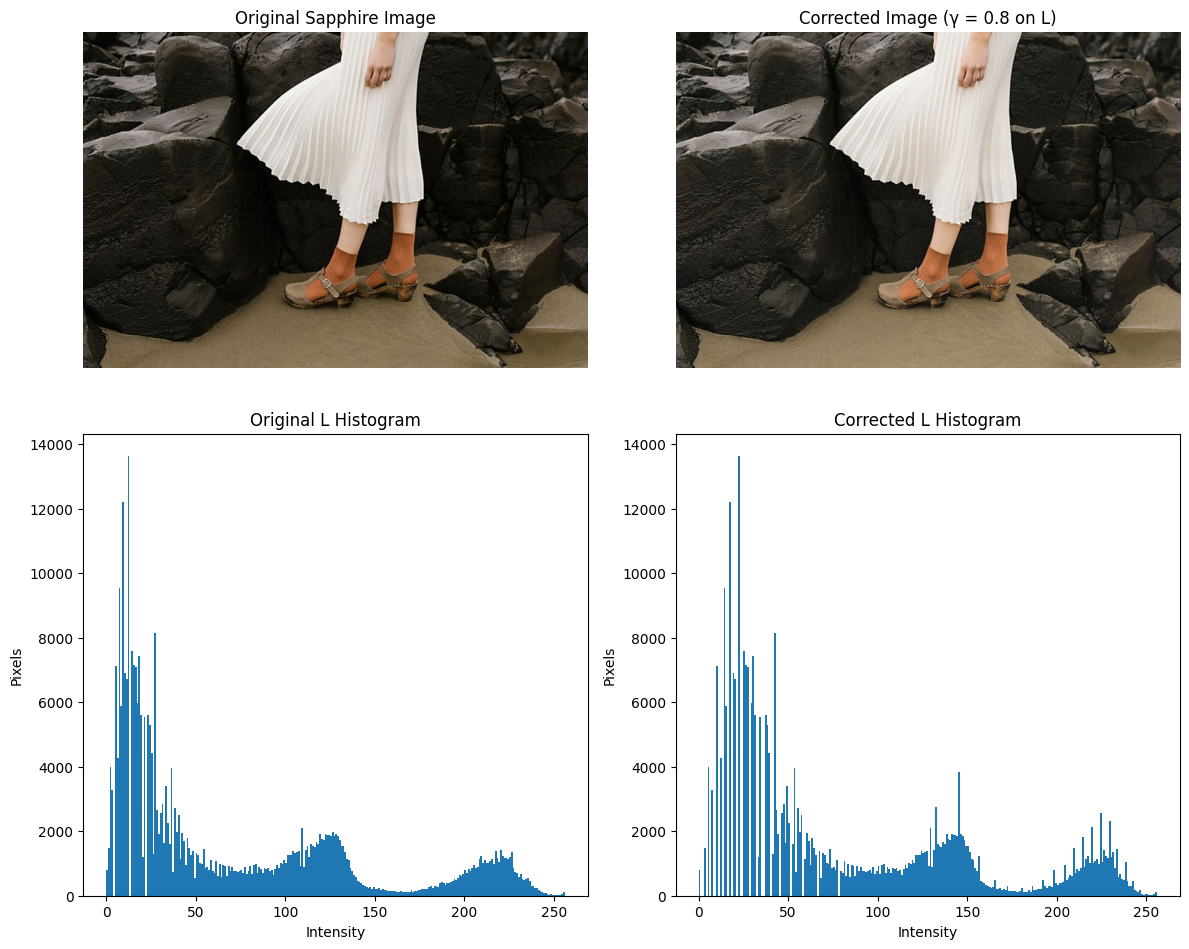

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].imshow(img_rgb)
axes[0,0].set_title('Original Sapphire Image')
axes[0,0].axis('off')

axes[0,1].imshow(img_corrected)
axes[0,1].set_title('Corrected Image (γ = 0.8 on L)')
axes[0,1].axis('off')

axes[1,0].hist(L.ravel(), bins=256, range=[0,256])
axes[1,0].set_title('Original L Histogram')
axes[1,0].set_xlabel('Intensity')
axes[1,0].set_ylabel('Pixels')

axes[1,1].hist(L_gamma_u8.ravel(), bins=256, range=[0,256])
axes[1,1].set_title('Corrected L Histogram')
axes[1,1].set_xlabel('Intensity')
axes[1,1].set_ylabel('Pixels')

plt.tight_layout()
plt.show()

#### Q2(a): The sapphire image was converted from RGB to L*a*b* color space. Gamma correction was then applied only to the L channel using γ=0.8. This choice slightly brightened the image while preserving the original color information in the a and b channels. The corrected image showed improved lightness and clearer gemstone detail without noticeable color distortion.

#### Q2(b): The histogram of the corrected L channel is slightly shifted toward higher intensity values compared to the original. This indicates that the image has been brightened. The transformation mainly affects shadow regions, improving visibility while maintaining the overall color appearance of the image.